In [5]:
!pip install nltk wordcloud kagglehub -q

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
import kagglehub

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print(path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
/kaggle/input/imdb-dataset-of-50k-movie-reviews


In [8]:
import os

csv_path = os.path.join(path, "IMDB Dataset.csv")

df = pd.read_csv(csv_path)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
df.info()

df['sentiment'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,count
sentiment,
positive,25000
negative,25000


In [10]:
neutral_reviews = [
    "The movie was okay and average.",
    "The acting was fine but nothing special.",
    "It was neither good nor bad.",
    "Average storyline with decent performances.",
    "The film was watchable.",
    "Nothing impressive but not disappointing.",
    "The movie had both strengths and weaknesses.",
    "Overall it was acceptable.",
    "The music was okay.",
    "An average experience."
]*500

neutral_df = pd.DataFrame({
    "review": neutral_reviews,
    "sentiment":"neutral"
})

df = pd.concat([df, neutral_df], ignore_index=True)

df['sentiment'].value_counts()


,count
sentiment,
positive,25000
negative,25000
neutral,5000


In [11]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [12]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])

y = df['sentiment']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
pred = model.predict(X_test)


In [16]:
accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.901090909090909


In [17]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4984
     neutral       1.00      1.00      1.00      1013
    positive       0.88      0.90      0.89      5003

    accuracy                           0.90     11000
   macro avg       0.93      0.93      0.93     11000
weighted avg       0.90      0.90      0.90     11000



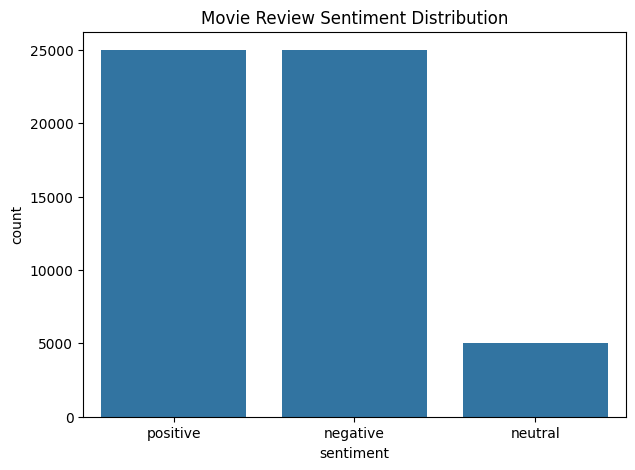

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(x=df['sentiment'])

plt.title("Movie Review Sentiment Distribution")

plt.show()

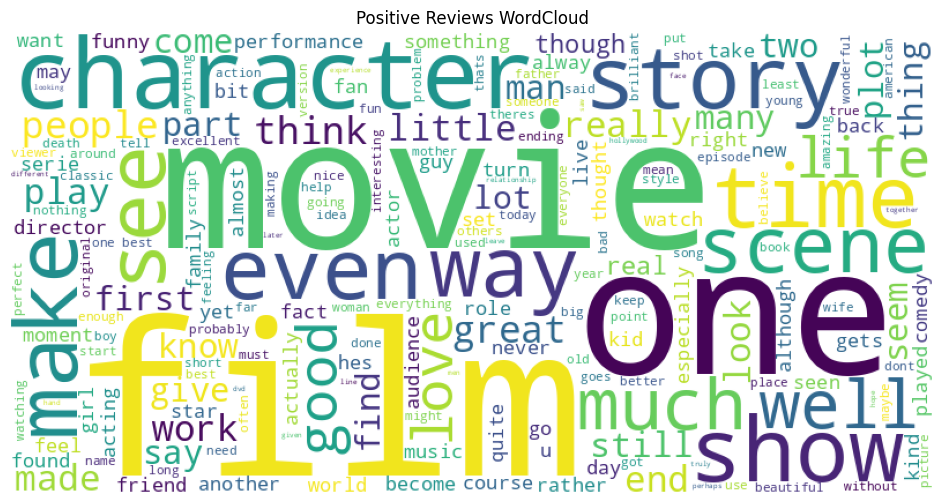

In [20]:
positive = " ".join(df[df.sentiment=="positive"]['clean_review'])

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.title("Positive Reviews WordCloud")

plt.show()

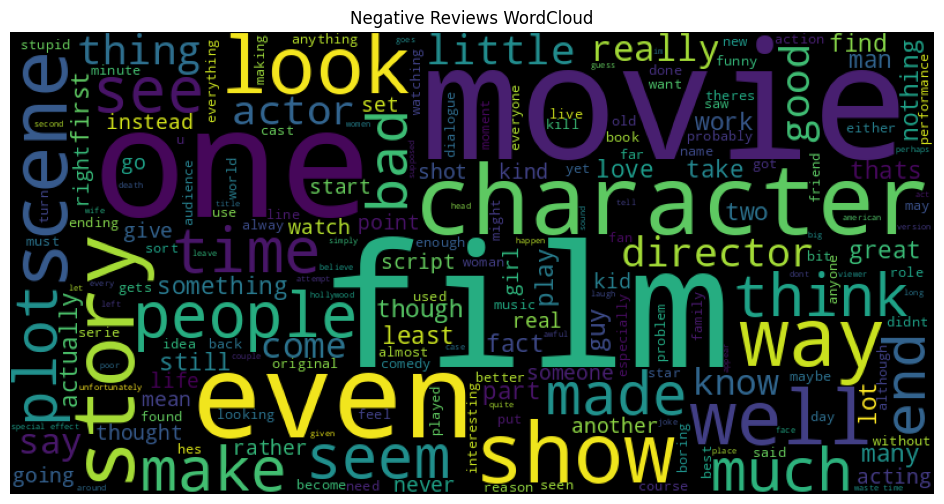

In [21]:
negative = " ".join(df[df.sentiment=="negative"]['clean_review'])

wc = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(negative)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.title("Negative Reviews WordCloud")

plt.show()

In [22]:
review = [
    "The movie was fantastic with brilliant acting.",
    "Worst movie ever made.",
    "The film was average and watchable."
]

review_clean = [clean_text(i) for i in review]

review_vector = tfidf.transform(review_clean)

prediction = model.predict(review_vector)

for r,p in zip(review,prediction):
    print(r)
    print("Prediction:",p)
    print()

The movie was fantastic with brilliant acting.
Prediction: positive

Worst movie ever made.
Prediction: negative

The film was average and watchable.
Prediction: neutral

